<a href="https://colab.research.google.com/github/AryamBajracharya/ML/blob/main/TensorFLow_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
#Normalize
X_train = X_train/255
X_test = X_test/255

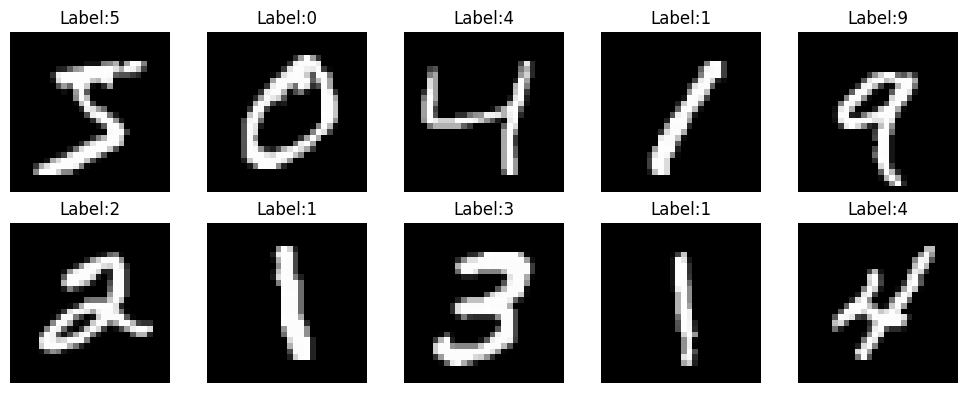

In [7]:
plt.figure(figsize = (10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap ='gray')
  plt.title(f"Label:{y_train[i]}")
  plt.axis('off')
plt.tight_layout()
plt.show()


In [8]:
# Build a neural network

model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),  # 1D = 28x28 = 700 something
    layers.Dense(128, activation='relu'),   # 128 = neurons
    layers.Dense(10, activation='softmax')  # probability
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5627 - loss: 1.7162 - val_accuracy: 0.8753 - val_loss: 0.5664
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8575 - loss: 0.5620 - val_accuracy: 0.9073 - val_loss: 0.3631
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8886 - loss: 0.4112 - val_accuracy: 0.9187 - val_loss: 0.3040
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8990 - loss: 0.3619 - val_accuracy: 0.9245 - val_loss: 0.2767
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9046 - loss: 0.3297 - val_accuracy: 0.9268 - val_loss: 0.2607
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9093 - loss: 0.3158 - val_accuracy: 0.9295 - val_loss: 0.2483
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9139 - loss: 0.3043 - val_accuracy: 0.9318 - val_loss: 0.2368
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9133 - loss: 0.2953 

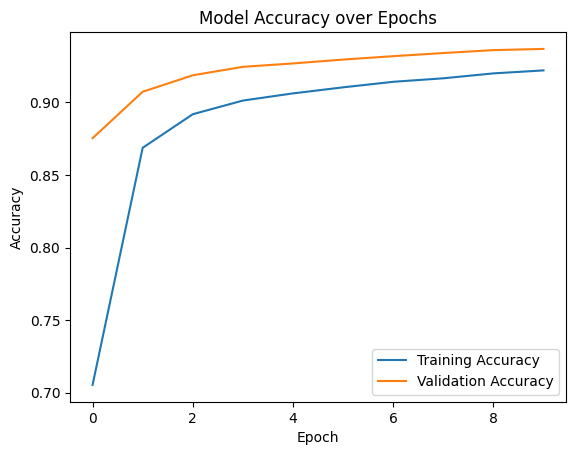

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy:{test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9165 - loss: 0.2925
Test accuracy:0.9271


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


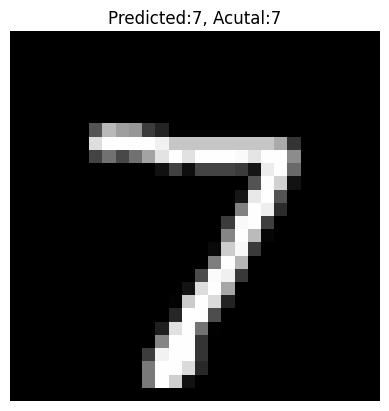

In [22]:
sample_image = np.expand_dims(X_test[0], axis=0)
prediction = model.predict(sample_image)

predicted_label = tf.argmax (prediction[0]).numpy()
plt.imshow(X_test[0], cmap='gray')
plt.title(f'Predicted:{predicted_label}, Acutal:{y_test[0]}')
plt.axis('off')
plt.show()


In [23]:
# NLP
(X_train, y_train), (X_test,y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
word_index = tf.keras.datasets.imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0] = '<PAD>'
index_word[1]= '<START>'
index_word[2]= '<UNK>'
index_word[3]= '<UNUSED>'

print('sample review:')
print(' '.join(index_word.get(i, '?') for i in X_train[0]))
print('Label:', y_train[0])

sample review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be 

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=256, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=256, padding='post', truncating='post')

In [28]:
model = models.Sequential([
    layers.Embedding(input_dim = 10000, output_dim = 16, input_length=256),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
model.compile(optimizer ='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
history = model.fit(X_train, y_train, epochs=10, batch_size=512, validation_split=0.2)   # batch_size garyo vane time badhi lagxa tara learning ramro hunxa

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8682 - loss: 0.3240 - val_accuracy: 0.8644 - val_loss: 0.3411
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8908 - loss: 0.2927 - val_accuracy: 0.8620 - val_loss: 0.3376
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8934 - loss: 0.2819 - val_accuracy: 0.8714 - val_loss: 0.3234
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8990 - loss: 0.2704 - val_accuracy: 0.8740 - val_loss: 0.3169
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9055 - loss: 0.2565 - val_accuracy: 0.8750 - val_loss: 0.3127
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9025 - loss: 0.2557 - val_accuracy: 0.8758 - val_loss: 0.3093
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9192 - loss: 0.2294 - val_accuracy: 0.8770 - val_loss: 0.3085
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9148 - loss: 0.2281 - val_accuracy: 0.8726 - val_los

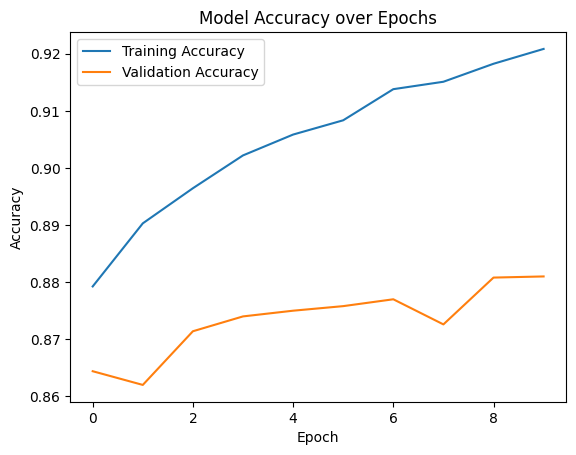

In [33]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy:{test_acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8651 - loss: 0.3167
Test accuracy:0.8668


In [36]:
sample_review = X_test[0]
sample_review_input = tf.expand_dims(sample_review, axis=0)
prediction = model.predict(sample_review_input)[0][0]

print(f"Predicted Sentiment: {'Postivie' if prediction > 0.5 else 'Negative'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Predicted Sentiment: Negative


In [37]:
sample_index = 0
decoded_review = " ".join(index_word.get(i, "?")for i in X_test[sample_index] if i !=0)

In [39]:
print(decoded_review)
print(y_test[0])

<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss
0
